In [2]:
# importing the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report

In [3]:
# data preprocessing
img_size = 128
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_path = path + "/chest_xray"
train_path = dataset_path + "/train"
test_path = dataset_path + "/test"
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray


In [9]:
# data preprocessing
img_size = 128
batch_size = 32
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
# loading the dataset
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
# building the cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# compiling the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# training the model
epochs = 5
history = model.fit(
    train_data,
    epochs=epochs,
    validation_data=test_data
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.8338 - loss: 0.3797 - val_accuracy: 0.8045 - val_loss: 0.4577
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9016 - loss: 0.2501 - val_accuracy: 0.8205 - val_loss: 0.4093
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.9095 - loss: 0.2218 - val_accuracy: 0.8061 - val_loss: 0.5395
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.9153 - loss: 0.2034 - val_accuracy: 0.8429 - val_loss: 0.3900
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.9214 - loss: 0.1876 - val_accuracy: 0.8622 - val_loss: 0.4491


In [14]:
# saving the model
model.save("cnn_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [15]:
# Probability and prediction
test_data.reset()
y_pred_prob = model.predict(test_data)

# First image probability
first_prob = y_pred_prob[0][0]
print(f"\nNormal Probability: {(1 - first_prob)*100:.2f}%")
print(f"Pneumonia Probability: {first_prob*100:.2f}%")
pred_class = "Pneumonia" if first_prob > 0.5 else "Normal"
confidence = first_prob if first_prob > 0.5 else (1 - first_prob)
print("\nFinal Prediction:", pred_class)
print("Confidence: {:.2f}%".format(confidence * 100))

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 492ms/step

Normal Probability: 96.75%
Pneumonia Probability: 3.25%

Final Prediction: Normal
Confidence: 96.75%


In [16]:
# Performance metrics

# Convert probabilities to labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_data.classes

# Accuracy
accuracy = np.mean(y_pred == y_true) * 100
print("\nCNN Accuracy: {:.2f}%".format(accuracy))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)


CNN Accuracy: 86.22%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.69      0.79       234
   Pneumonia       0.84      0.96      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624


Confusion Matrix:
 [[162  72]
 [ 14 376]]


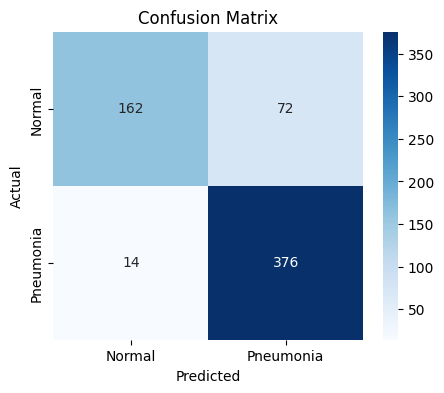

In [17]:
# confusion matrix graph
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 426ms/step
Cluster 0 → Avg label: 0.22433460076045628
Cluster 1 → Avg label: 0.9168975069252078


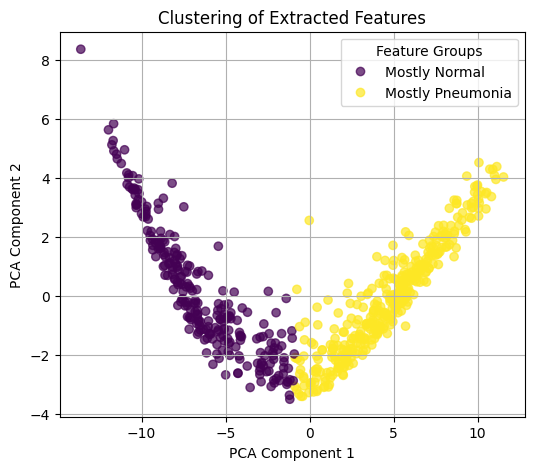

In [21]:
# Exploratory Analysis

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Extracting features using CNN
feature_model = Sequential(model.layers[:-1])
features = feature_model.predict(test_data)

# Step 2: Reducing dimensions using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

# Step 3: Applying KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(reduced)

# Step 4: Comparing clusters with actual labels
y_true = test_data.classes

for i in range(2):
    print(f"Cluster {i} → Avg label:", np.mean(y_true[clusters == i]))

# Step 5: Assigning meaningful names based on above output
labels = ["Mostly Normal", "Mostly Pneumonia"]

# Step 6: Plotting clustering result
plt.figure(figsize=(6,5))

scatter = plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

handles, _ = scatter.legend_elements()
plt.legend(handles, labels, title="Feature Groups")

plt.title("Clustering of Extracted Features")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(True)
plt.show()